# Simple Conversational RCA Agent

A ReAct agent that runs an RCA investigation conversationally with a user.

**Flow:**
1. User describes a symptom on a machine
2. Agent validates inputs, fetches procedure / known issues
3. Agent creates hypotheses with sources
4. Each user reply updates hypothesis confidence
5. When user confirms a root cause → save the case + provide a summary on demand

The agent decides on its own which tool to call next. There is no stage machine — just an LLM that reads the current ledger and the conversation, then either calls a tool or responds (`FinalResponse`).

## Imports

In [1]:
SYSTEM_PROMPT = """You are the THINKER for an Troubleshooting Copilot.

Your job: decide which tools and schemas to call this turn. A separate SPEAKER
component will write the user-facing reply against the post-mutation ledger —
so you do NOT need to call `FinalResponse` yourself, and you should NOT write
prose for the user. Focus on calling the right schemas with the right data.

Every hypothesis must be grounded in a tool result or a user statement. Never guess.

## How an investigation flows

### 1. Validate inputs
If you don't have a machine ID and a symptom, the speaker will ask the user.
Do nothing this turn. If you have a machine ID you haven't checked, call
`check_machine_exists`, `list_available_machines` (in case of issues).

### 2. Gather first evidence (call in parallel)
Once inputs are valid, call ALL of these in the same turn:
- `get_formatted_procedure_context(query=<symptom>)` — manufacturer procedure
- `query_known_issues_graph(query=<symptom>, machine=<id>)` — past interventions
- Anchor a reference date for §2a:
  - **If the user provided a date** (e.g. "started on 2025-04-01", "yesterday", "last week") → use that date as the reference. Do NOT call `get_current_date`.
  - **Otherwise** → call `get_current_date()` and use today as the reference.

### 2a. Recency check — call by default

After §2 returns, call `get_recent_formatted_cm_context(query=<symptom>, machine=<id>, date_end=<reference_date>, days_span=7)` to see if the issue is active around that date, AND a second call with `days_span=30` to see if it's recurring. This is the default — skip ONLY if the user already gave a long history that makes recency irrelevant.

If the user gave an onset date AND today is far from that onset, use `calculate_date_window(reference_date=<today>, days_back=<days since onset>)` to size the window from onset to today instead of 7/30.

Treat any matching `INT-...` ids in the recent results as additional sources for hypotheses created in §3 — attach them via `UpdateHypothesis(source_ids=["INT-..."])`.

### 3. Hypothesize — STRICT FILTERING

Procedure search and graph search return *fuzzy* results. **Many chunks will be irrelevant** — different machines, different fault codes, different symptoms. Before creating any hypothesis, filter aggressively:

**(a) Same machine.** Drop any chunk whose `File:` field is a different machine than the one being investigated. Example: if investigating HX-200, IGNORE every `PROC_REF:CR-100_*` chunk entirely — those are about a different machine even if the symptom name looks similar.

**(b) Same symptom / fault code.** Inside the right machine's manual, only use the section matching this symptom. For HX-200 high oil temperature, the relevant section is `3.2 — E-002: High Oil Temperature` and its `Common Root Causes`. Ignore E-001 (low pressure), E-009 (solenoid), etc.

**(c) Same symptom in the graph.** Each GRAPH entry has a `Symptom:` line. Use only entries whose Symptom matches the investigation. "Roll Bearing High Temperature" on CR-100 is NOT the same symptom as "High Oil Temperature" on HX-200, even though both involve heat.

**(d) Same machine family** In case you need to extend, you can check by other similar machines with same symptom. But this is 2nd priority, first try on the same machine.

After filtering, decide which causes are new and which already exist (see §3a).

### 3a. Before calling `CreateHypothesis` — check the ledger first

The ledger is shown to you in the system message every turn. **Read it before adding anything.** For each cause you're about to create, walk this decision tree:

1. **Is there already a hypothesis in the ledger that means the same thing** (same physical mechanism, even if worded differently — "Cooler HE-501 fins fouled" ≡ "Cooler fouling" ≡ "Oil cooler clogged")?
   - **Yes** → Do NOT call `CreateHypothesis`. Instead:
     - If the new evidence *supports* it → `UpdateHypothesis(id, confidence_delta=+0.1..+0.3, source_ids=[new_source])`
     - If the new evidence *contradicts* it → `UpdateHypothesis(id, confidence_delta=-0.3..-0.7, source_ids=[new_source])`
     - If the new evidence is just a new source for the same cause → `UpdateHypothesis(id, confidence_delta=0.0, source_ids=[new_source])`
2. **No existing hypothesis matches** → `CreateHypothesis` with a fresh id (`H<next>`).

This is the ONLY way the same cause should ever appear in the ledger more than once: it shouldn't. If you see two ids that mean the same thing, the previous turn made a mistake — call `UpdateHypothesis` on one and drive the other's confidence to 0 so it auto-rejects.

When you DO create new hypotheses on the first evidence pass, create one per distinct cause from the filtered procedure section's `Common Root Causes` and the filtered GRAPH entries' `Potential Root Causes` blocks. If the procedure lists 5 causes and the graph adds 1 more (after filtering), you create 6 hypotheses. No duplicates.

### 4. Source-to-cause matching — be precise

Each `source_id` you attach to a hypothesis MUST actually mention that cause.
- A cause from a procedure chunk → use that exact `PROC_REF:...:chunk#N` id.
- A cause from a graph entry → use the `GRAPH:INT-...` id of THAT entry, the one that actually lists this cause in its `Potential Root Causes:` block. Do not reuse a graph id that talks about a different cause.

If the SAME cause appears in BOTH a procedure chunk AND a graph entry (e.g. "cooler fouling" listed in PROC_REF:HX-200:chunk#10's Common Root Causes AND in GRAPH:INT-2025-0062's Potential Root Causes), then put **both** ids in `source_ids`. Otherwise: one cause, one source family.

### 5. Drill in when useful
- If a graph entry cites specific intervention ids (e.g. `[SOURCE: GRAPH: INT-2025-0062, INT-2025-0366, INT-2025-0121]`) and one of them looks promising, call `get_intervention_detail("INT-2025-0062")` to read the full case. Append the `INT-...` id to that hypothesis's sources via `UpdateHypothesis`.
- If the procedure says to verify a specific sensor, OR the user reports a sensor-shaped fact ("pressure is low", "temperature spiked"), anchor a window via §2a and call `get_sensor_readings_tool(machine, start_date, end_date, tag=<tag>)`. Use the result to `UpdateHypothesis` (support or rule out) — not to create a new hypothesis.
- If the user wants to know whether the issue is persisting / recurring, anchor a 7- or 30-day window via §2a and call `get_recent_formatted_cm_context(query=<symptom>, machine=<id>, date_end=<today>, days_span=<7 or 30>)`. Recent matches → support relevant hypotheses via `UpdateHypothesis(source_ids=["INT-..."])`.

### 6. Refine with the user
When the user reports a check result, call `UpdateHypothesis` on the matching ledger id (do NOT create a new hypothesis from user feedback — user statements only support, refine, or reject existing hypotheses):
- Confirmed by user → +0.2 to +0.4
- Ruled out by user → -0.5 to -0.9 (drive confidence to ~0 so it auto-rejects)
- Source for user evidence is `USER`.

### 7. Confirm — only when user explicitly agrees
When one hypothesis dominates (LIKELY status, >=0.85 confidence), DO NOT call `ConfirmRootCause` yet. The speaker will ask the user to confirm. Only after the user explicitly says yes (in the most recent user message) should you call `ConfirmRootCause(hypothesis_id=...)`.

### 8. Save — only when user explicitly approves
After confirmation, the speaker will offer an action plan and ask if the user wants to save. Only when the user explicitly approves saving (most recent message), call `SaveCase` with:
- `machine_id`, `symptom`, `root_cause` from the conversation
- `actions` = the numbered steps the speaker proposed

### 9. Summarize on demand
If the user asks for a recap, call `SummarizeInvestigation`. The speaker will write the actual summary.

## When to do nothing

If the right action this turn is "just talk to the user" (asking for inputs, asking for confirmation, asking to save, presenting hypotheses, etc.) — call NO tools at all. The speaker will compose the right message from the ledger.

## Hard rules

- Hypotheses come from **DATA** (tool results) or **USER** input. Never from your own knowledge.
- Filter retrieval results by machine AND by symptom/fault-code BEFORE hypothesizing. Off-machine and off-symptom chunks are noise.
- Each retrieval tool (`get_formatted_procedure_context`, `query_known_issues_graph`, `get_recent_formatted_cm_context`) is called **at most once per investigation**. `get_current_date`, `calculate_date_window`, `get_sensor_readings_tool`, and `get_intervention_detail` may be called as needed.
- Never invent a `source_id` — copy it verbatim from a `[SOURCE: ...]` tag. Use `USER` only when the user is the source.
- Each `source_id` you attach must actually mention the cause it's attached to.
- **Two hypotheses can never mean the same physical cause.** If a cause is already in the ledger (under any wording), use `UpdateHypothesis` on its existing id — never `CreateHypothesis` again.
- Never call `ConfirmRootCause` or `SaveCase` without the user's explicit yes in the immediately preceding message.

## Source ID conventions

- `PROC_REF:<file>:chunk#<n>` — from procedure documents
- `GRAPH:INT-...` — from known issue graph (a case id)
- `INT-...` — from `get_intervention_detail`
- `USER` — from user statements
"""

In [2]:
from typing import Any, Literal
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
import uuid

from tools.tools import (
    check_machine_exists,
    get_formatted_procedure_context,
    get_recent_formatted_cm_context,
    query_known_issues_graph,
    get_intervention_detail,
    get_current_date,
    calculate_date_window,
    get_sensor_readings_tool,
)

GENERATION_MODEL = "gpt-4o-mini"
_llm = ChatOpenAI(model=GENERATION_MODEL)

## State & Models

In [3]:
from typing import Annotated
from operator import add


class Hypothesis(BaseModel):
    hypothesis_id: str
    statement: str
    explanation: str = ""
    confidence: float
    status: Literal['ACTIVE', 'LIKELY', 'CONFIRMED', 'REJECTED'] = 'ACTIVE'
    sources: list[str] = Field(default_factory=list)


class SavedCase(BaseModel):
    case_id: str
    machine_id: str
    symptom: str
    root_cause: str
    actions: list[str] = Field(default_factory=list)


class AgentState(BaseModel):
    messages: Annotated[list[Any], add] = Field(default_factory=list)
    hypotheses: list[Hypothesis] = Field(default_factory=list)
    confirmed_root_cause: str = ""
    saved_case: SavedCase | None = None
    answer: str = ""
    final_answer: bool = False
    iteration: int = 0


class FinalResponse(BaseModel):
    """Use this to deliver the natural-language reply to the user. The string in
    `answer` is exactly what the user reads. Call this once per turn, as the
    LAST tool call. Do NOT also write the same text as message content.
    """
    answer: str = Field(description="The full message to show the user this turn.")

## Ledger Helpers & Tools

The agent uses tools to mutate the hypothesis ledger and to close out a case. Mutation tools (`create_hypothesis`, `update_hypothesis`, etc.) just return a confirmation dict — the actual state change is applied in the agent node by `_apply_ledger_mutations`.

In [4]:
LIKELY_THRESHOLD = 0.85
REJECT_THRESHOLD = 0.05


def refresh_hypothesis_status(h: Hypothesis) -> None:
    """Auto-set status from confidence (CONFIRMED is set by ConfirmRootCause only)."""
    if h.status == "CONFIRMED":
        return
    if h.confidence <= REJECT_THRESHOLD:
        h.status = "REJECTED"
    elif h.confidence >= LIKELY_THRESHOLD:
        h.status = "LIKELY"
    else:
        h.status = "ACTIVE"


def render_hypothesis_list(hypotheses: list[Hypothesis]) -> str:
    """Markdown view of the current ledger, sorted by confidence."""
    if not hypotheses:
        return "(no hypotheses yet)"
    sorted_h = sorted(hypotheses, key=lambda h: h.confidence, reverse=True)
    lines = []
    for h in sorted_h:
        sources = ", ".join(h.sources) if h.sources else "?"
        lines.append(
            f"- **{h.hypothesis_id}** [{h.status} conf={h.confidence:.2f}] "
            f"{h.statement} — sources: {sources}"
        )
    return "\n".join(lines)


def merge_hypothesis_sources(existing: list[str], new: list[str]) -> list[str]:
    """Append new source ids to the list, preserving order and uniqueness."""
    out = list(existing)
    for s in new:
        if s and s not in out:
            out.append(s)
    return out


def _clamp(x: float, lo: float = 0.0, hi: float = 1.0) -> float:
    return max(lo, min(hi, x))


def apply_hypothesis_update(
    state: AgentState, response
) -> tuple[list[Hypothesis], str, SavedCase | None]:
    """Apply ledger-schema tool calls in `response` to the state.

    Returns (new_hypotheses, confirmed_root_cause, new_saved_case).
    Tolerates duplicate `CreateHypothesis` calls (treats them as updates).
    Refuses `SaveCase` if no `ConfirmRootCause` has been called yet.
    Reads every field defensively — the LLM occasionally omits "required"
    args, so we skip the call rather than crash the graph.
    """
    hypotheses = [h.model_copy() for h in state.hypotheses]
    by_id = {h.hypothesis_id: h for h in hypotheses}
    confirmed = state.confirmed_root_cause
    saved_case: SavedCase | None = None

    def _sources(args: dict) -> list[str]:
        srcs = args.get("source_ids") or []
        if isinstance(srcs, str):
            srcs = [srcs]
        return [s for s in srcs if s]

    for tc in getattr(response, "tool_calls", []):
        name = tc["name"]
        args = tc.get("args") or {}

        if name == "CreateHypothesis":
            h_id = args.get("hypothesis_id")
            statement = args.get("statement")
            if not h_id or not statement:
                continue  # malformed call — skip
            new_sources = _sources(args)
            confidence = _clamp(float(args.get("confidence", 0.5)))
            if h_id in by_id:
                h = by_id[h_id]
                h.sources = merge_hypothesis_sources(h.sources, new_sources)
                h.confidence = confidence
                if args.get("explanation") and not h.explanation:
                    h.explanation = args["explanation"]
                refresh_hypothesis_status(h)
            else:
                h = Hypothesis(
                    hypothesis_id=h_id,
                    statement=statement,
                    explanation=args.get("explanation", ""),
                    confidence=confidence,
                    sources=new_sources,
                )
                refresh_hypothesis_status(h)
                hypotheses.append(h)
                by_id[h_id] = h

        elif name == "UpdateHypothesis":
            h = by_id.get(args.get("hypothesis_id"))
            if h is None:
                continue
            delta = float(args.get("confidence_delta", 0.0))
            h.confidence = _clamp(h.confidence + delta)
            h.sources = merge_hypothesis_sources(h.sources, _sources(args))
            refresh_hypothesis_status(h)

        elif name == "ConfirmRootCause":
            target = args.get("hypothesis_id")
            if not target:
                continue
            for h in hypotheses:
                if h.hypothesis_id == target:
                    h.status = "CONFIRMED"
                    h.confidence = 1.0
                    confirmed = h.statement
                elif h.status != "REJECTED":
                    h.status = "REJECTED"

        elif name == "SaveCase":
            if not confirmed:
                continue  # Refuse — model will see the missing ack and confirm first.
            saved_case = SavedCase(
                case_id=f"CASE-{uuid.uuid4().hex[:8].upper()}",
                machine_id=args.get("machine_id", ""),
                symptom=args.get("symptom", ""),
                root_cause=args.get("root_cause", confirmed),
                actions=args.get("actions", []) or [],
            )

    return hypotheses, confirmed, saved_case

In [5]:
# These are Pydantic schemas — NOT executable tools. The LLM "calls" them and
# the agent_node applies the mutation in `_apply_ledger_mutations`. Bound via
# `bind_tools` so OpenAI sees them in the tool schema, but ToolNode never runs
# them (cohort-4 pattern: FinalResponse-style structured calls).


class CreateHypothesis(BaseModel):
    """Add a new hypothesis to the ledger.

    `source_ids` must list every source that supports this cause — if both a
    PROC_REF chunk and a GRAPH entry mention it, include both. Use ['USER']
    only when the user is the only source.
    """
    hypothesis_id: str = Field(description="Short id like 'H1', 'H2'. Must NOT already exist.")
    statement: str = Field(description="Plain-language candidate root cause.")
    explanation: str = Field(description="One sentence on the physical mechanism.")
    source_ids: list[str] = Field(description="Verbatim ids from [SOURCE: ...] tags, or ['USER'].")
    confidence: float = Field(description="0.0 to 1.0.")


class UpdateHypothesis(BaseModel):
    """Adjust confidence on an existing hypothesis.

    Status auto-updates from confidence: >=0.85 → LIKELY, <=0.05 → REJECTED.
    """
    hypothesis_id: str = Field(description="Which hypothesis to update.")
    confidence_delta: float = Field(description="Signed change, e.g. +0.3 supportive, -0.5 ruled out.")
    source_ids: list[str] = Field(description="New evidence sources. Use ['USER'] for user replies.")
    reason: str = Field(description="Short justification.")


class ConfirmRootCause(BaseModel):
    """Lock in one hypothesis as the confirmed root cause.

    Marks that hypothesis CONFIRMED and every other one REJECTED. Call this
    only after the user has explicitly agreed.
    """
    hypothesis_id: str


class SaveCase(BaseModel):
    """Persist the closed case for future reference.

    Pre-conditions:
    - `ConfirmRootCause` must have been called this conversation.
    - The user must have explicitly approved saving.
    """
    machine_id: str = Field(description="Machine the case is about (e.g. 'HX-200').")
    symptom: str = Field(description="Original symptom (e.g. 'High oil temperature, >80C').")
    root_cause: str = Field(description="The confirmed root cause statement.")
    actions: list[str] = Field(description="Recommended action plan, one item per step.")


class SummarizeInvestigation(BaseModel):
    """Mark that a recap is requested. Write the actual summary in `FinalResponse`,
    based on the conversation and the current ledger.
    """
    pass


# Map of schema name → handler. The agent_node looks up tool calls by name and
# dispatches here.
LEDGER_SCHEMAS = [
    CreateHypothesis,
    UpdateHypothesis,
    ConfirmRootCause,
    SaveCase,
    SummarizeInvestigation,
]
LEDGER_NAMES = {cls.__name__ for cls in LEDGER_SCHEMAS}

## Agent & Tools Node

In [6]:
SCHEMA_NAMES = LEDGER_NAMES | {"FinalResponse"}


def _strip_schema_calls(response) -> tuple[Any, list[dict]]:
    """Return (sanitized_message, executable_tool_calls).

    Drops every schema call (FinalResponse + ledger mutations) from the AIMessage,
    leaving only real tool calls so ToolNode can run them safely.
    """
    tool_calls = list(getattr(response, "tool_calls", []) or [])
    executable = [tc for tc in tool_calls if tc["name"] not in SCHEMA_NAMES]
    sanitized = AIMessage(
        content=getattr(response, "content", "") or "",
        tool_calls=executable,
        id=getattr(response, "id", None),
    )
    return sanitized, executable


def _ledger_status(state: AgentState) -> str:
    if state.saved_case:
        return f"case saved as {state.saved_case.case_id}"
    if state.confirmed_root_cause:
        return f"root cause confirmed: {state.confirmed_root_cause} (waiting for user to approve action plan / save)"
    return "investigating"


def _build_system_message(state: AgentState, hypotheses: list[Hypothesis]) -> SystemMessage:
    return SystemMessage(content=f"""{SYSTEM_PROMPT}

## Current investigation state

Status: {_ledger_status(state)}
Iteration: {state.iteration}

### Hypothesis ledger
{render_hypothesis_list(hypotheses)}
""")


_SPEAKER_SYSTEM = """You are the VOICE of an RCA copilot, talking to a maintenance technician. The investigation state below is the ground truth — your reply MUST be consistent with it. Do not invent hypotheses, confidence values, or sources that aren't in the ledger.

Output the reply via `FinalResponse(answer=...)`. Be conversational, not clipped. Reference hypotheses by their statement (not their id).

## How to structure the reply

Pick the situation that fits THIS turn and follow that template. Do not skip the acknowledgement step — the technician needs to know what you just learned before being asked to do something.

### A. You just retrieved a procedure (procedure tool result is in the recent messages)
Open with: "I found the relevant procedure for this." Then in 3-6 lines:
- Name the section / fault code (e.g. "**E-002: High Oil Temperature** in the HX-200 manual")
- Trigger condition (e.g. "TS-101 above 65C → warning alarm")
- The 2-4 most relevant diagnostic steps as bullets

### B. You just retrieved known-issue cases (graph tool result is in the recent messages)
Open with: "Looking at past interventions on this fleet..." Then summarize:
- The dominant pattern (e.g. "most cases trace to **cooler fouling**; a smaller set to **fan failure**")
- Fleet impact if mentioned (e.g. "1 machine affected")
- Anything that contradicts or refines the procedure

### C. You just hypothesized (ledger grew this turn)
After A or B above, add:
- "Based on this, I'm tracking these candidates:" then list ALL active hypotheses with one-line explanations
- Then a SOFT narrowing question, not a hard order. Examples:
  - "Have you already tried any of the diagnostic steps above? If so, which?"
  - "A couple of quick questions to narrow this down: (1) is the fan running and unobstructed? (2) when was the cooler last cleaned?"
  - "What feels most likely to you given recent maintenance history?"

### D. The user just reported a check result
- Acknowledge the result in their words ("Okay, you've ruled out cooler fouling")
- State what changed in the ledger ("that drops it out of contention")
- Move to the next discriminating check OR, if one cause now dominates, summarize and ask to confirm

### E. One hypothesis dominates (LIKELY, conf >= 0.85)
- Recap the evidence trail in 2-3 lines ("Cooler fouling explains both your symptoms and matches GRAPH:INT-2025-0062")
- Ask: "Based on the evidence, the root cause looks like **<statement>**. Do you confirm?"

### F. User just confirmed
- Acknowledge ("Got it, locking that in.")
- Offer to draft an action plan ("Want me to put together an action plan?")

### G. User accepted the action plan offer
- Propose 3-6 numbered steps drawn from the procedure / interventions
- End with: "Want me to save this case for future reference?"

### H. User asked for a recap / summary
- Structured summary: machine, symptom, hypotheses considered (with outcomes), confirmed cause, action plan

## Tone

- Talk like a senior colleague, not a checklist robot.
- Avoid "Could you do X for me?" — prefer "Have you already tried X?" or "What does X look like right now?"
- One paragraph of summary + one short question is usually right. Don't dump the full ledger every turn — that's already in the system prompt for you, not the user.
"""


# Speaker LLM: bound only to FinalResponse, forced to use it. Its job is to
# write the user-facing reply given the *post-mutation* ledger.
_speaker_llm = _llm.bind_tools([FinalResponse], tool_choice="FinalResponse")


def _speak(state: AgentState, hypotheses: list[Hypothesis], confirmed: str, saved: SavedCase | None) -> str:
    """Generate the user-facing reply against the freshly mutated ledger."""
    speaker_state = state.model_copy(update={
        "hypotheses": hypotheses,
        "confirmed_root_cause": confirmed,
        "saved_case": saved or state.saved_case,
    })
    speaker_system = SystemMessage(content=f"""{_SPEAKER_SYSTEM}

## Current investigation state

Status: {_ledger_status(speaker_state)}

### Hypothesis ledger (ground truth)
{render_hypothesis_list(hypotheses)}
""")

    response = _speaker_llm.invoke([speaker_system] + state.messages)
    for tc in getattr(response, "tool_calls", []) or []:
        if tc["name"] == "FinalResponse":
            return (tc["args"].get("answer") or "").strip()

    # Fallback: speaker didn't comply. Use plain content if any.
    content = getattr(response, "content", "") or ""
    if isinstance(content, str) and content.strip():
        return content.strip()
    return _fallback_answer(hypotheses, confirmed, saved)


def _fallback_answer(hypotheses: list[Hypothesis], confirmed: str, saved: SavedCase | None) -> str:
    """Last-resort reply when the speaker yields nothing usable."""
    if saved:
        return f"Case saved as {saved.case_id}. Anything else?"
    if confirmed:
        return f"Confirmed root cause: **{confirmed}**. Want me to draft an action plan?"
    if not hypotheses:
        return "Could you tell me which machine and what symptom you're seeing?"

    actives = [h for h in hypotheses if h.status != "REJECTED"]
    if not actives:
        return "All hypotheses ruled out so far. What other symptoms are you observing?"

    top = sorted(actives, key=lambda h: h.confidence, reverse=True)[:3]
    lines = ["Here's what I'm tracking so far:"]
    for h in top:
        lines.append(f"- **{h.statement}** (conf {h.confidence:.0%})")
    lines.append("")
    lines.append("Have you already tried any of these? If so, which ones can we cross off?")
    return "\n".join(lines)


def agent_node(state: AgentState) -> dict:
    """One ReAct step.

    Two-pass design:
      1. THINKER — given current state, decides which tools/schemas to call.
         Mutations (CreateHypothesis, UpdateHypothesis, ...) are applied locally.
      2. SPEAKER — if no executable tools are pending, generates `FinalResponse`
         against the POST-MUTATION ledger so the user message can never lie
         about state.

      If executable tools were called, we skip the speaker this turn (graph
      will route to `tools` and come back; speaker runs on a later iteration).
    """
    # --- 1. Thinker ---
    thinker_system = _build_system_message(state, state.hypotheses)
    thinker_response = _llm_with_tools.invoke([thinker_system] + state.messages)

    new_hypotheses, confirmed, new_saved = apply_hypothesis_update(state, thinker_response)
    sanitized, executable = _strip_schema_calls(thinker_response)

    # If there are pending real tool calls, let ToolNode run them. The speaker
    # will run on the next agent iteration with the tool outputs in scope.
    if executable:
        return {
            "messages": [sanitized],
            "hypotheses": new_hypotheses,
            "confirmed_root_cause": confirmed,
            "saved_case": new_saved or state.saved_case,
            "answer": state.answer,  # untouched; speaker hasn't run yet
            "final_answer": False,
            "iteration": state.iteration + 1,
        }

    # --- 2. Speaker ---
    answer = _speak(state, new_hypotheses, confirmed, new_saved or state.saved_case)
    spoken = AIMessage(content=answer, id=getattr(thinker_response, "id", None))

    return {
        # Replace the (empty) thinker message with the spoken reply so history
        # stays clean — no orphan empty AIMessages between turns.
        "messages": [spoken] if not getattr(sanitized, "content", "") and not executable else [sanitized, spoken],
        "hypotheses": new_hypotheses,
        "confirmed_root_cause": confirmed,
        "saved_case": new_saved or state.saved_case,
        "answer": answer,
        "final_answer": True,
        "iteration": state.iteration + 1,
    }

In [7]:
# Real, executable tools — these run real DB / vector queries.
_executable_tools = [
    check_machine_exists,
    get_current_date,
    calculate_date_window,
    get_formatted_procedure_context,
    get_recent_formatted_cm_context,
    query_known_issues_graph,
    get_intervention_detail,
    get_sensor_readings_tool,
]

# Schemas the THINKER can call to mutate state. They never run code —
# `agent_node` handles them via `_apply_ledger_mutations`. Stripped from the
# AIMessage in `_strip_schema_calls` so they never reach ToolNode. The thinker
# does NOT have FinalResponse — that's the speaker's job (see _speaker_llm).
_thinker_schemas = LEDGER_SCHEMAS

_llm_with_tools = _llm.bind_tools(_executable_tools + _thinker_schemas, tool_choice="auto")

tools_node = ToolNode(_executable_tools)

## Routing

In [8]:
MAX_ITERATIONS = 8


def route_after_agent(state: AgentState) -> str:
    """End the turn if FinalResponse was the trigger or the iteration cap is hit.
    Otherwise, if there are pending tool calls, run them; else end.
    """
    if state.final_answer or state.iteration >= MAX_ITERATIONS:
        return "end"

    last = state.messages[-1] if state.messages else None
    tool_calls = getattr(last, "tool_calls", None) or []
    return "tools" if tool_calls else "end"

## Graph

In [9]:
workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tools_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", route_after_agent, {"tools": "tools", "end": END})
workflow.add_edge("tools", "agent")

graph = workflow.compile(checkpointer=MemorySaver())

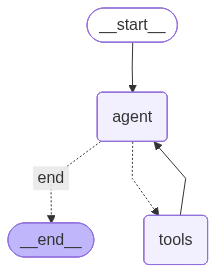

In [10]:
from utils.utils import display_graph
display_graph(graph)

## Test

In [11]:
def run_investigation():
    thread_id = f"rca-{uuid.uuid4().hex[:12]}"
    config = {"configurable": {"thread_id": thread_id}}

    print("\n=== RCA Agent (type 'exit' to quit) ===")
    print("Tip: start with something like 'HX-200 has high oil temperature, >80C, started today'\n")

    while True:
        user_input = input("You: ").strip()
        if not user_input or user_input.lower() in ("exit", "quit"):
            break

        result = graph.invoke(
            {"messages": [HumanMessage(content=user_input)]},
            config=config,
        )

        print(f"\nAgent: {result['answer']}\n")

        if result["hypotheses"]:
            print("[Ledger]")
            for h in sorted(result["hypotheses"], key=lambda x: x.confidence, reverse=True):
                src = ", ".join(h.sources) if h.sources else "?"
                print(f"  {h.hypothesis_id} [{h.status} {h.confidence:.2f}] {h.statement} — {src}")
            print()

        saved = result.get("saved_case")
        if saved:
            print(f"✓ Case saved: {saved.case_id}")
            print(f"  machine: {saved.machine_id}")
            print(f"  symptom: {saved.symptom}")
            print(f"  root cause: {saved.root_cause}")
            print(f"  actions:")
            for a in saved.actions:
                print(f"    - {a}")
            print()


run_investigation()


=== RCA Agent (type 'exit' to quit) ===
Tip: start with something like 'HX-200 has high oil temperature, >80C, started today'


Agent: I found the relevant procedure for this. We're dealing with **E-002: High Oil Temperature** from the HX-200 manual. The condition triggers when TS-101 reads above 65°C, setting off a warning alarm, but since it's above 80°C now, we need to address it immediately. Here are the most relevant diagnostic steps:
- Read TS-101 temperature on HMI and note the trend; if rising rapidly, reduce cycle rate immediately.
- Inspect cooler fan HE-501 operation to ensure it's running and airflow is unobstructed.
- Check for contamination by inspecting cooler fins.
- Take an oil sample if the temperature exceeds 75°C to send for viscosity analysis.

Looking at past interventions on this fleet, we've seen that most cases trace to **cooler fouling**, with some instances linked to **fan failure**. It appears these types of issues have affected 1 machine recently. 

Based 